# 4. Rispondere alle domande
Trasforma le seguenti richiesti in formule per estrarre infromazioni dal dataframe
- Mostrami le vendite maggiori di 10

- Mostrami i dati del 2018

- Mostrami le vendite maggiori di 13 e l'anno è il 2018

- Mostrami tutto TRANNE i casi in cui le vendite sono maggiori di 13 e l'anno è il 2018

- Mostrami i dati dove le vendite divise per 3 sono maggiori di 3

- Mostrami i dipendenti i cui nomi sono alfabeticamente dopo la J



In [1]:
import pandas as pd

sales = pd.DataFrame(
    data={
        "employee": [
            "Katrina",
            "Guanyu",
            "Jan",
            "Roman",
            "Jacqueline",
            "Paola",
            "Esperanza",
            "Alaina",
            "Egweyn",
        ],
        "sales": [14, 17, 6, 12, 8, 3, 7, 15, 5],
        "year": [2018, 2019, 2020, 2018, 2020, 2019, 2019, 2020, 2020],
    }
)
sales

sales[sales["sales"] > 10]
sales[sales["year"] == 2018]
sales[(sales["sales"] > 13) & (sales["year"] == 2018)]
sales[~((sales["sales"] > 13) & (sales["year"] == 2018))]
sales[(sales["sales"] / 3) > 3]
sales[sales["employee"] > "J"]

,employee,sales,year
0,Katrina,14,2018
2,Jan,6,2020
3,Roman,12,2018
4,Jacqueline,8,2020
5,Paola,3,2019


In [2]:
sales.query('employee > "J"')
sales.query("sales > 10")
sales.query("year == 2018")
sales.query("sales > 13 and year == 2018")
sales.query("not (sales > 13 and year == 2018)")
sales.query('employee > "J"')


,employee,sales,year
0,Katrina,14,2018
2,Jan,6,2020
3,Roman,12,2018
4,Jacqueline,8,2020
5,Paola,3,2019


# 5. Analisi di un dataset di video giochi
1. Quanti videogiochi sono stati pubblicati
2. Quali sono i generi più popolari? Mostralo con un bar plot
3. Plotta l'evoluzione del numero di giochi pubblicati nel tempo
4. Prova a riprodurre questo plot 

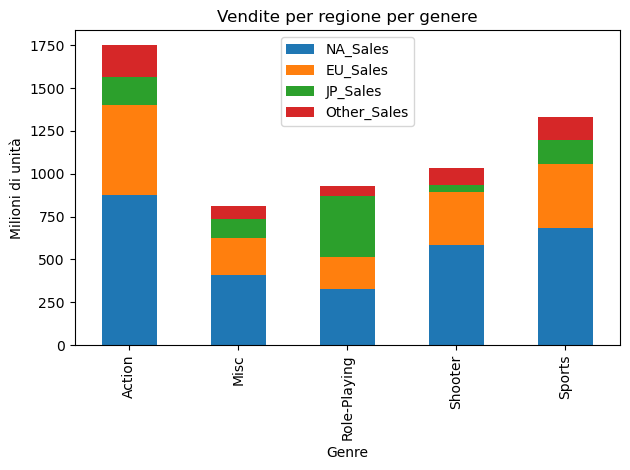


In [4]:
# Import dei pacchetti
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Caricamento del dataset
url = 'https://zenodo.org/record/5898311/files/vgsales.csv'
df = pd.read_csv(url)
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


Nel dataset sono presenti 16598 titoli/versioni di videogiochi.
I titoli unici di videogiochi sono 11493.
Genre
Action          3316
Sports          2346
Misc            1739
Role-Playing    1488
Shooter         1310
Adventure       1286
Racing          1249
Platform         886
Simulation       867
Fighting         848
Strategy         681
Puzzle           582
Name: count, dtype: int64


C:\Users\hp\AppData\Local\Temp\ipykernel_21276\3978544030.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Genre', order=generi_popolari.index, palette='viridis')


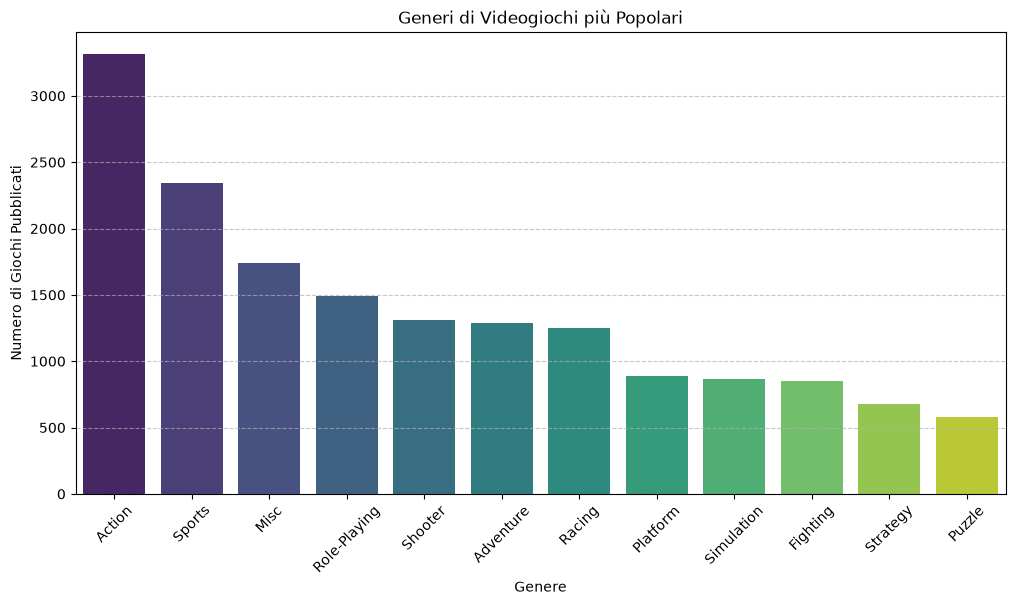

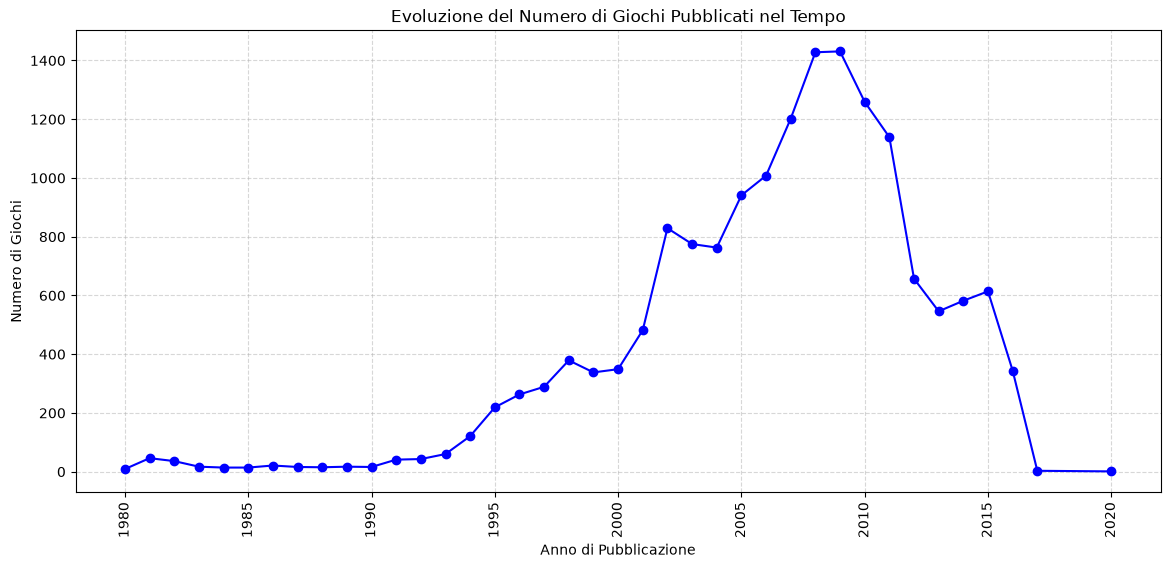

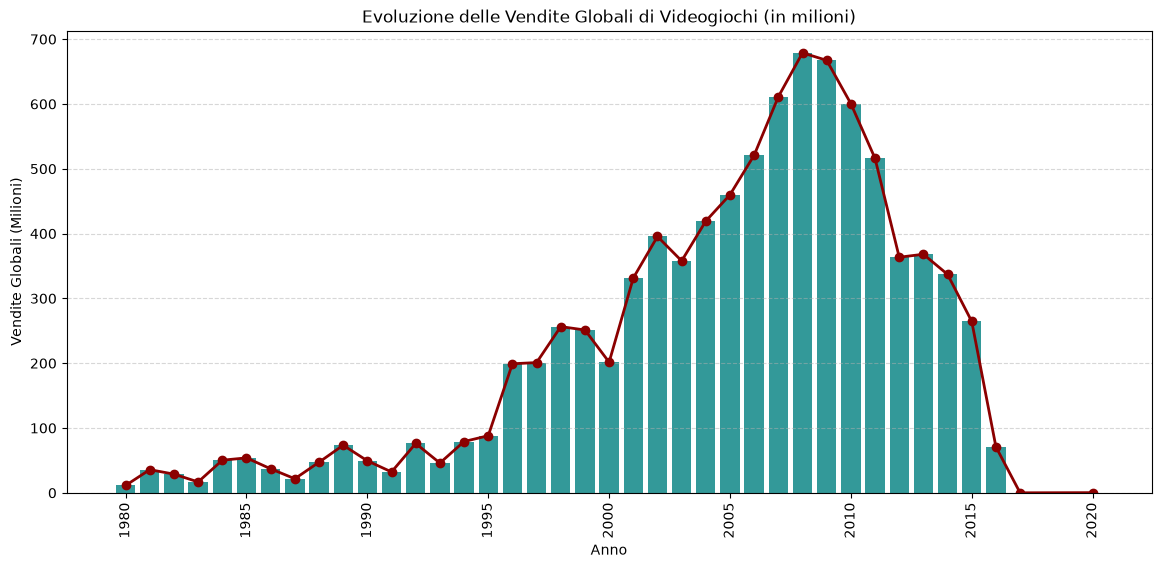

In [5]:
# Numero totale di record nel dataset
totale_giochi = len(df)
print(f"Nel dataset sono presenti {totale_giochi} titoli/versioni di videogiochi.")

# Se vuoi contare i titoli unici escludendo le versioni per console diverse:
giochi_unici = df['Name'].nunique()
print(f"I titoli unici di videogiochi sono {giochi_unici}.")

# Conteggio dei giochi per genere
generi_popolari = df['Genre'].value_counts()
print(generi_popolari)

# Creazione del Bar Plot
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Genre', order=generi_popolari.index, palette='viridis')
plt.title('Generi di Videogiochi più Popolari')
plt.xlabel('Genere')
plt.ylabel('Numero di Giochi Pubblicati')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Raggruppamento per anno e conteggio dei giochi
giochi_per_anno = df.groupby('Year').size()

# Creazione del Line Plot
plt.figure(figsize=(14, 6))
plt.plot(giochi_per_anno.index, giochi_per_anno.values, marker='o', color='b', linestyle='-')
plt.title('Evoluzione del Numero di Giochi Pubblicati nel Tempo')
plt.xlabel('Anno di Pubblicazione')
plt.ylabel('Numero di Giochi')
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Raggruppiamo le vendite globali per anno
vendite_per_anno = df.groupby('Year')['Global_Sales'].sum()

plt.figure(figsize=(14, 6))
plt.bar(vendite_per_anno.index, vendite_per_anno.values, color='teal', alpha=0.8)
plt.plot(vendite_per_anno.index, vendite_per_anno.values, color='darkred', marker='o', linewidth=2)
plt.title('Evoluzione delle Vendite Globali di Videogiochi (in milioni)')
plt.xlabel('Anno')
plt.ylabel('Vendite Globali (Milioni)')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()